# SDA: Fitting diffuse interstellar bands (DIBs)

We will use data from the ESO Diffuse Interstellar Bands Large Exploration Survey (EDIBLES). The data were obtained with observations with the Ultraviolet and Visual Echelle Spectrograph (UVES) on the Very Large Telescope (VLT) at Cerro Paranal in Chile. The data file includes a small part of the complete spectrum, covering a diffuse interstellar band (DIB).

The data are available on [Github](https://github.com/jancami/edibles) and the related publication can be found through [ADS](https://ui.adsabs.harvard.edu/abs/2017A%26A...606A..76C).

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import ascii
from scipy import stats

In [11]:
plt.rcParams["figure.figsize"] = (6, 3)
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

## Read the data

In [12]:
dibs_data = ascii.read("dibs_data.csv", format="csv")
print(dibs_data)

Wavelength   Flux 
---------- -------
 5768.8198 272.857
 5768.8398 273.178
 5768.8599 273.242
 5768.8799 272.953
 5768.8999 273.004
 5768.9199 273.436
 5768.9399 273.502
   5768.96 273.476
   5768.98 273.265
    5769.0 273.061
       ...     ...
 5770.0601 273.563
 5770.0801 273.304
 5770.1001 273.096
 5770.1201 273.018
 5770.1401 272.939
 5770.1602 272.822
 5770.1802 273.379
 5770.2002 272.946
 5770.2202 273.212
 5770.2402 273.196
Length = 72 rows


We add an approximate (constant) uncertainty, by adopting the approximate S/N of 700 from the article

In [13]:
dibs_data['e_Flux'] = dibs_data['Flux']/700

## Plot the spectrum

Let's first plot the data to have a look at the spectral DIB feature.

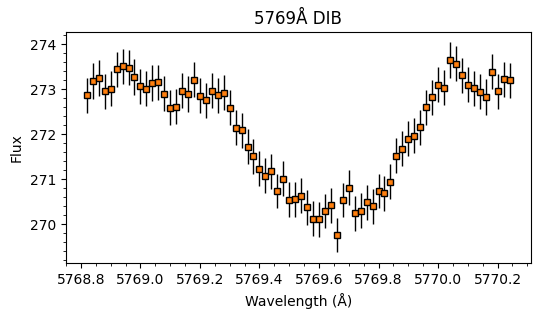

In [14]:
plt.errorbar(dibs_data['Wavelength'], dibs_data['Flux'], yerr=dibs_data['e_Flux'],
             marker='s', ms=5, ls='none', color='tab:orange', ecolor='black', mec='black', mew=1, elinewidth=1)
plt.title('5769Å DIB')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.show()

## Define functions for the line profiles

Next, we define functions for a [Gaussian](https://en.wikipedia.org/wiki/Normal_distribution) and [Lorentzian](https://en.wikipedia.org/wiki/Spectral_line_shape#Lorentzian) line profile.

In [15]:
def gaussian_profile(wavelength, continuum, amplitude, w0, sigma):
    """
    Gaussian absorption line profile.

    Parameters
    ----------
    wavelength : array
        Wavelength values (same units as w0).
    continuum : float
        Constant continuum level.
    amplitude : float
        Depth of the absorption line.
    w0 : float
        Central wavelength of the line.
    sigma : float
        Standard deviation of the line profile.

    Returns
    -------
    flux : array
        Model flux at each wavelength.
    """

    # Normalized Gaussian profile
    profile = np.exp(-0.5 * ((wavelength - w0) / sigma)**2)

    # Absorption line: continuum minus Gaussian profile
    return continuum - amplitude * profile

In [16]:
def lorentzian_profile(wavelength, continuum, amplitude, w0, fwhm):
    """
    Lorentzian absorption line profile.

    Parameters
    ----------
    wavelength : array
        Wavelength values (same units as w0).
    continuum : float
        Constant continuum level.
    amplitude : float
        Depth of the absorption line.
    w0 : float
        Central wavelength of the line.
    fwhm : float
        Full width at half maximum (FWHM) of the line profile.

    Returns
    -------
    flux : array
        Model flux at each wavelength.
    """

    # Normalized Lorentzian profile
    profile = 1 / (1 + ((wavelength - w0) / (fwhm / 2))**2)

    # Absorption line: continuum minus Lorentzian profile
    return continuum - amplitude * profile

## Exercises

**Question 1**: Use the least-squares method to find the best-fit Gaussian and Lorentzian model parameters.

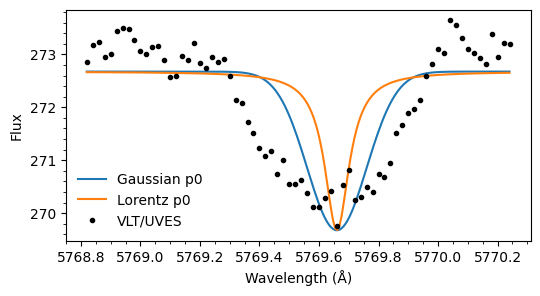

In [17]:
from scipy.optimize import curve_fit

# We first have to make an approximate guess of the parameters values

p0=[
    np.median(dibs_data['Flux']),                          # The median flux for the continuum.
    3,                                                     # The line looks visually about 3 flux units deep.
    dibs_data['Wavelength'][np.argmin(dibs_data['Flux'])], # The wavelength where the flux is lowest.
    .1                                                     # The line looks visually about 0.1 Å wide.
    ]

wavel_grid = np.linspace(np.min(dibs_data['Wavelength']), np.max(dibs_data['Wavelength']), 200)

# Let's check if p0 is indeed a reasonable guess

plt.figure(figsize=(6, 3))
plt.plot(wavel_grid, gaussian_profile(wavel_grid, *p0), label='Gaussian p0')
plt.plot(wavel_grid, lorentzian_profile(wavel_grid, *p0), label='Lorentz p0')
plt.plot(dibs_data['Wavelength'], dibs_data['Flux'], 'o', ms=3, color='black', label='VLT/UVES')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.minorticks_on()
plt.legend(frameon=False)
plt.show()

In [18]:
# Run the non-linear least squares optimization function of SciPy
# for the Gaussian absorption line profile. Use absolute_sigma=True
# if we believe the uncertainty of the data, as reported in the article.

popt_gaussian, pcov_gaussian = curve_fit(
    gaussian_profile,
    dibs_data['Wavelength'],
    ydata=dibs_data['Flux'],
    sigma=dibs_data['e_Flux'],
    p0=p0,
    absolute_sigma=True
)

In [19]:
popt_lorentzian, pcov_lorentzian = curve_fit(
    lorentzian_profile,
    dibs_data['Wavelength'],
    ydata=dibs_data['Flux'],
    sigma=dibs_data['e_Flux'],
    p0=p0,
    absolute_sigma=True
)

If needed, have a look at this [refresher](https://www.geeksforgeeks.org/python/args-kwargs-python/) on passing a variable number of arguments to a function as `*args`, which is simply more convenient than passing all the arguments of the model parameters individually.

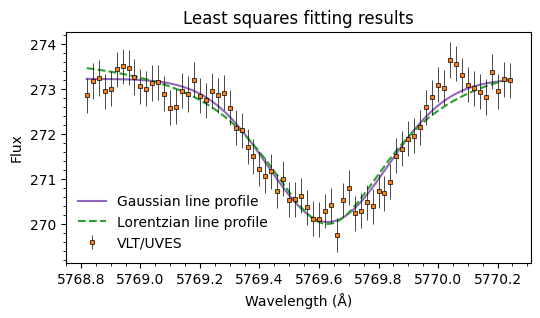

In [20]:
plt.plot(wavel_grid, gaussian_profile(wavel_grid, *popt_gaussian), '-',
         lw=1.5, label='Gaussian line profile', color='tab:purple')
plt.plot(wavel_grid, lorentzian_profile(wavel_grid, *popt_lorentzian), '--',
         lw=1.5, label='Lorentzian line profile', color='tab:green')
plt.errorbar(dibs_data['Wavelength'], dibs_data['Flux'], yerr=dibs_data['e_Flux'],
             marker='s', ms=3, ls='none', color='tab:orange', ecolor='black',
             mec='black', mew=0.5, elinewidth=0.5, label='VLT/UVES')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.title('Least squares fitting results')
plt.legend(loc='lower left', frameon=False)
plt.show()

In [21]:
print('Results for Gaussian profile:')
for i, param in enumerate(['Continuum', 'Line strength', 'Line center (Å)', 'Line width (Å)']):
    print(f'   - {param}: {popt_gaussian[i]:.3f} +/- {np.sqrt(pcov_gaussian[i, i]):.3f}')

Results for Gaussian profile:
   - Continuum: 273.224 +/- 0.089
   - Line strength: 3.176 +/- 0.129
   - Line center (Å): 5769.630 +/- 0.008
   - Line width (Å): 0.202 +/- 0.011


In [22]:
print('Results for Lorentzian profile:')
for i, param in enumerate(['Continuum', 'Line strength', 'Line center (Å)', 'Line width (Å)']):
    print(f'   - {param}: {popt_lorentzian[i]:.3f} +/- {np.sqrt(pcov_lorentzian[i, i]):.3f}')

Results for Lorentzian profile:
   - Continuum: 273.849 +/- 0.164
   - Line strength: 3.844 +/- 0.167
   - Line center (Å): 5769.628 +/- 0.008
   - Line width (Å): 0.541 +/- 0.049


**Question 2**: Compute the reduced $\chi^2$ of the best-fit model. Can you conclude anything about the reported uncertainties of the data?

In [23]:
best_model = gaussian_profile(dibs_data['Wavelength'], *popt_gaussian)
chi2_gaussian = np.sum((best_model-dibs_data['Flux'])**2/dibs_data['e_Flux']**2)
dof = len(dibs_data)-len(p0)
print(f'Gaussian profile chi2/dof: {chi2_gaussian/dof:0.2f}')

Gaussian profile chi2/dof: 0.54


In [24]:
best_model = lorentzian_profile(dibs_data['Wavelength'], *popt_lorentzian)
chi2_lorentzian = np.sum((best_model-dibs_data['Flux'])**2/dibs_data['e_Flux']**2)
dof = len(dibs_data)-len(p0)
print(f'Lorentzian profile chi2/dof: {chi2_lorentzian/dof:0.2f}')

Lorentzian profile chi2/dof: 0.74


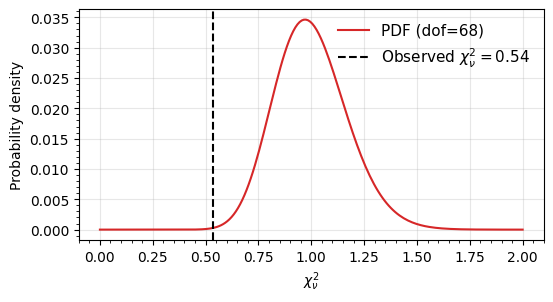


The observed reduced chi-square is 0.54.
This is somewhat smaller than 1, suggesting that the data
uncertainties might be overestimated.



In [25]:
chi2_grid = np.linspace(0, 2*dof, 200)
plt.plot(chi2_grid/dof, stats.chi2.pdf(chi2_grid, df=dof), '-', label=f'PDF (dof={dof})', color='tab:red')
plt.axvline(chi2_gaussian/dof, ls='--', lw=1.5, color='black', label=rf'Observed $\chi^2_\nu = {chi2_gaussian/dof:.2f}$')
plt.xlabel(r'$\chi^2_\nu$')
plt.ylabel('Probability density')
plt.grid(alpha=0.3)
plt.legend(loc='upper right', frameon=False, fontsize=11)
plt.show()

print(f"""
The observed reduced chi-square is {chi2_gaussian/dof:.2f}.
This is somewhat smaller than 1, suggesting that the data
uncertainties might be overestimated.
""")

**Question 3**: Compute the log-likelihood for the best-fit Gaussian model and for the best-fit Lorentzian model. Then calculate the likelihood ratio between the two models. What can you conclude?

In [35]:
# loglikelihood best fit gaussian
def loglikelihood_gaussian(wavelength, flux, e_flux, continuum, amplitude, w0, sigma):
    model_flux = gaussian_profile(wavelength, continuum, amplitude, w0, sigma)
    residuals = flux - model_flux
    logL = -0.5 * np.sum((residuals / e_flux)**2 + np.log(2 * np.pi * e_flux**2))
    return logL
logL_gaussian = loglikelihood_gaussian(dibs_data['Wavelength'], dibs_data['Flux'], dibs_data['e_Flux'], *popt_gaussian)
print(f'Log-likelihood for Gaussian fit: {logL_gaussian:.2f}')

# loglikelihood best fit lorentzian
def loglikelihood_lorentzian(wavelength, flux, e_flux, continuum, amplitude, w0, fwhm):
    model_flux = lorentzian_profile(wavelength, continuum, amplitude, w0, fwhm)
    residuals = flux - model_flux
    logL = -0.5 * np.sum((residuals / e_flux)**2 + np.log(2 * np.pi * e_flux**2))
    return logL
logL_lorentzian = loglikelihood_lorentzian(dibs_data['Wavelength'], dibs_data['Flux'], dibs_data['e_Flux'], *popt_lorentzian)
print(f'Log-likelihood for Lorentzian fit: {logL_lorentzian:.2f}')
delta_logL = np.exp(logL_gaussian - logL_lorentzian)
print(f'Log-likelihood ratio (Gaussian/Lorentzian): {delta_logL:.2f}')

Log-likelihood for Gaussian fit: -16.36
Log-likelihood for Lorentzian fit: -23.17
Log-likelihood ratio (Gaussian/Lorentzian): 909.10


**Question 4**: Plot the continuum and the line profile separately for both the Gaussian and Lorentzian models.

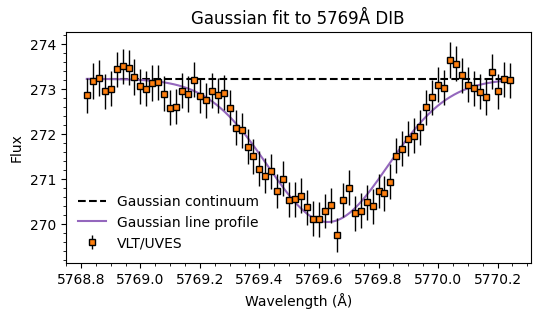

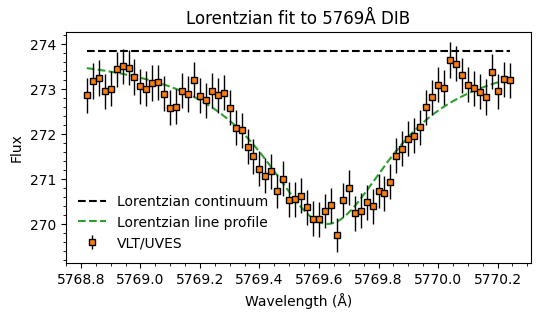

In [34]:
continu_gauss = popt_gaussian[0]
continu_lorentz = popt_lorentzian[0]
plt.plot([wavel_grid[0], wavel_grid[-1]], [continu_gauss, continu_gauss], '--', color='black', label='Gaussian continuum')
plt.plot(wavel_grid, gaussian_profile(wavel_grid, *popt_gaussian), '-', lw=1.5, label='Gaussian line profile', color='tab:purple')
plt.errorbar(dibs_data['Wavelength'], dibs_data['Flux'], yerr=dibs_data['e_Flux'],
             marker='s', ms=5, ls='none', color='tab:orange', ecolor='black', mec='black', mew=1, elinewidth=1, label='VLT/UVES')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.title('Gaussian fit to 5769Å DIB')
plt.legend(loc='lower left', frameon=False)
plt.show()

plt.plot([wavel_grid[0], wavel_grid[-1]], [continu_lorentz, continu_lorentz], '--', color='black', label='Lorentzian continuum')
plt.plot(wavel_grid, lorentzian_profile(wavel_grid, *popt_lorentzian), '--', lw=1.5, label='Lorentzian line profile', color='tab:green')
plt.errorbar(dibs_data['Wavelength'], dibs_data['Flux'], yerr=dibs_data['e_Flux'],
             marker='s', ms=5, ls='none', color='tab:orange', ecolor='black', mec='black', mew=1, elinewidth=1, label='VLT/UVES')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.title('Lorentzian fit to 5769Å DIB')
plt.legend(loc='lower left', frameon=False)
plt.show()

**Bonus question**: Plot the residuals of the best-fit Gaussian and Lorentzian models in a two-panel figure.

In [28]:
# ...